# 🎮 Clasificación Supervisada — Steam Games
## Parte 2: Diseño Experimental, Implementación y Análisis de Resultados

**Objetivo:** Predecir si un juego de Steam será exitoso en base a sus tags.  
**Modelos comparados:** Random Forest vs Logistic Regression  
**Librería:** scikit-learn

---

### Flujo del análisis

```
Dataset → Features (tags) + Target (Exitoso)
→ Train/Test Split → Entrenamiento → Evaluación → Comparación → Ejemplos
```


## ⚙️ Instalación y Librerías

In [1]:
# pip install scikit-learn matplotlib seaborn pandas numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    classification_report, RocCurveDisplay, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


---
## Paso 1 — Carga y Preparación de Datos

Cada fila del dataset representa un juego de Steam.  
Las **134 columnas `tag_*`** (binarias 0/1) son nuestros **features**.  
La columna **`Exitoso`** (0/1) es nuestro **target**.

> ⚠️ **Sin data leakage:** columnas como `ReviewScore`, `PositiveRatio` o `TotalReviews`  
> fueron excluidas porque son *consecuencia* del éxito, no predictores de él.


In [2]:
df = pd.read_csv("SteamGames_prepared.csv")

tag_cols = [c for c in df.columns if c.startswith("tag_")]
X = df[tag_cols].copy()
y = df["Exitoso"].copy()

n_exitosos = y.sum()
n_no_exit  = (y == 0).sum()
pct_exit   = y.mean() * 100

print(f"Total de juegos        : {len(df):,}")
print(f"Features (tags)        : {len(tag_cols)}")
print(f"Juegos exitosos        : {n_exitosos:,}  ({pct_exit:.1f}%)")
print(f"Juegos no exitosos     : {n_no_exit:,}  ({100-pct_exit:.1f}%)")
print(f"Valores nulos en X     : {X.isnull().sum().sum()}")


Total de juegos        : 22,531
Features (tags)        : 134
Juegos exitosos        : 15,504  (68.8%)
Juegos no exitosos     : 7,027  (31.2%)
Valores nulos en X     : 0


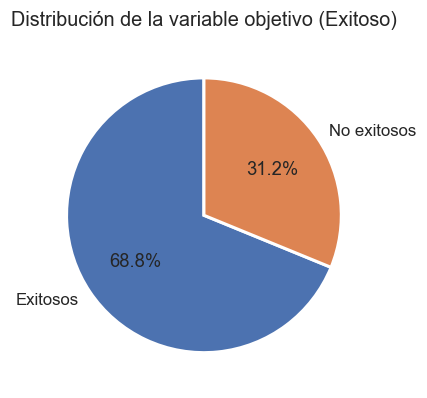

In [3]:
# Distribución del target
fig, ax = plt.subplots(figsize=(4, 4))
ax.pie(
    [n_exitosos, n_no_exit],
    labels=["Exitosos", "No exitosos"],
    autopct="%1.1f%%",
    colors=["#4C72B0", "#DD8452"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
ax.set_title("Distribución de la variable objetivo (Exitoso)", fontsize=13, pad=12)
plt.tight_layout()
plt.show()


---
## Paso 2 — División Train / Test

**Estrategia: Holdout 80% / 20% estratificado**

| Parámetro | Valor | Justificación |
|---|---|---|
| `test_size` | 20% | ~4,500 juegos de test, suficiente para métricas estables |
| `stratify` | `y` | Mantiene proporción 69/31 en ambos conjuntos |
| `random_state` | 42 | Reproducibilidad |


In [4]:
TEST_SIZE    = 0.20
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Train : {len(X_train):,} juegos  ({y_train.mean()*100:.1f}% exitosos)")
print(f"Test  : {len(X_test):,} juegos  ({y_test.mean()*100:.1f}% exitosos)")


Train : 18,024 juegos  (68.8% exitosos)
Test  : 4,507 juegos  (68.8% exitosos)


---
## Paso 3 — Definición de Modelos

Se comparan dos clasificadores con enfoques complementarios:

### Modelo 1: Random Forest
Ensemble de árboles de decisión. Captura relaciones **no lineales** entre tags  
(ej: la combinación `2d + indie` puede ser más poderosa que cada tag por separado).  
`class_weight='balanced'` ajusta los pesos para mitigar el desbalance 69/31.

### Modelo 2: Logistic Regression
Modelo lineal que estima `P(Exitoso=1 | tags)`.  
Sus **coeficientes son directamente interpretables**: cada tag suma o resta  
probabilidad de éxito. Sirve como baseline sólida para comparar.


In [5]:
modelos = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        solver="lbfgs"
    )
}

print("Modelos definidos:")
for nombre, m in modelos.items():
    print(f"  ✓ {nombre}")


Modelos definidos:
  ✓ Random Forest
  ✓ Logistic Regression


---
## Paso 4 — Entrenamiento y Evaluación

Para cada modelo:
1. Entrenar con `X_train`, `y_train`
2. Predecir sobre `X_test` (datos nunca vistos durante el entrenamiento)
3. Calcular métricas sobre `y_test` vs predicciones

**Métricas utilizadas:**

| Métrica | Qué mide |
|---|---|
| Accuracy | % total de predicciones correctas |
| Precision | De los predichos como exitosos, ¿cuántos lo son? |
| Recall | De los exitosos reales, ¿cuántos detectó el modelo? |
| F1-Score | Media armónica de precision y recall |
| ROC-AUC | Capacidad de discriminar clases (0.5=azar, 1=perfecto) |


In [6]:
resultados = {}

for nombre, modelo in modelos.items():
    print(f"Entrenando {nombre}...", end=" ", flush=True)
    modelo.fit(X_train, y_train)
    
    y_pred  = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    resultados[nombre] = {
        "modelo"     : modelo,
        "y_pred"     : y_pred,
        "y_proba"    : y_proba,
        "accuracy"   : accuracy_score(y_test, y_pred),
        "precision"  : precision_score(y_test, y_pred),
        "recall"     : recall_score(y_test, y_pred),
        "f1"         : f1_score(y_test, y_pred),
        "roc_auc"    : roc_auc_score(y_test, y_proba),
        "conf_matrix": confusion_matrix(y_test, y_pred)
    }
    print("listo ✓")


Entrenando Random Forest... listo ✓
Entrenando Logistic Regression... listo ✓


---
## Paso 5 — Comparación de Resultados


In [7]:
# Tabla comparativa
metricas      = ["accuracy", "precision", "recall", "f1", "roc_auc"]
nombres_metr  = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

tabla = pd.DataFrame(
    {nombre: [res[m] for m in metricas] for nombre, res in resultados.items()},
    index=nombres_metr
).round(4)
tabla["Diferencia (RF - LR)"] = tabla["Random Forest"] - tabla["Logistic Regression"]
tabla.style.format("{:.4f}").background_gradient(subset=["Random Forest", "Logistic Regression"], cmap="Blues")


,Random Forest,Logistic Regression,Diferencia (RF - LR)
Accuracy,0.6989,0.6268,0.0721
Precision,0.7307,0.7751,-0.0444
Recall,0.8907,0.6446,0.2461
F1-Score,0.8028,0.7039,0.0989
ROC-AUC,0.6610,0.6640,-0.0030


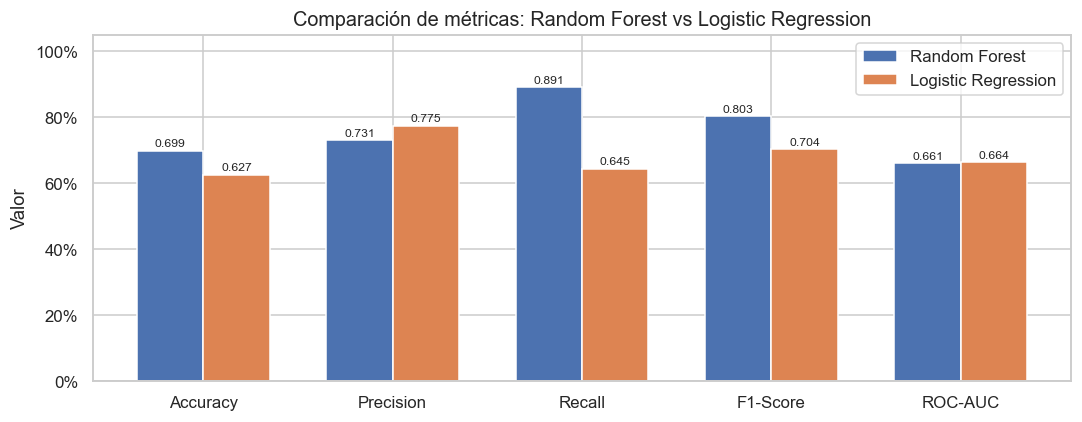

In [8]:
# Gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(10, 4))
x     = np.arange(len(nombres_metr))
ancho = 0.35
colores = ["#4C72B0", "#DD8452"]

for i, (nombre, res) in enumerate(resultados.items()):
    vals = [res[m] for m in metricas]
    bars = ax.bar(x + i * ancho, vals, ancho, label=nombre, color=colores[i], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + ancho / 2)
ax.set_xticklabels(nombres_metr)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Valor")
ax.set_title("Comparación de métricas: Random Forest vs Logistic Regression", fontsize=13)
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()


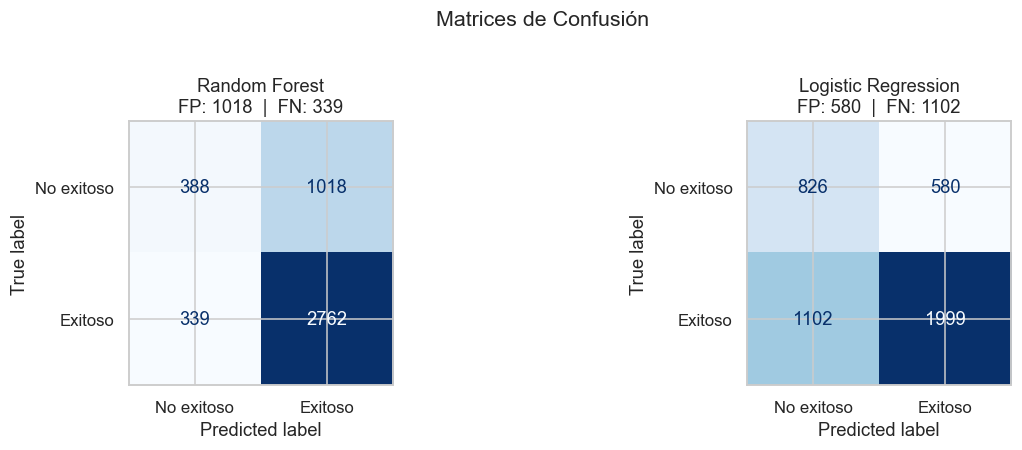

In [9]:
# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (nombre, res) in zip(axes, resultados.items()):
    cm = res["conf_matrix"]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No exitoso", "Exitoso"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{nombre}\nFP: {fp}  |  FN: {fn}", fontsize=12)

plt.suptitle("Matrices de Confusión", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


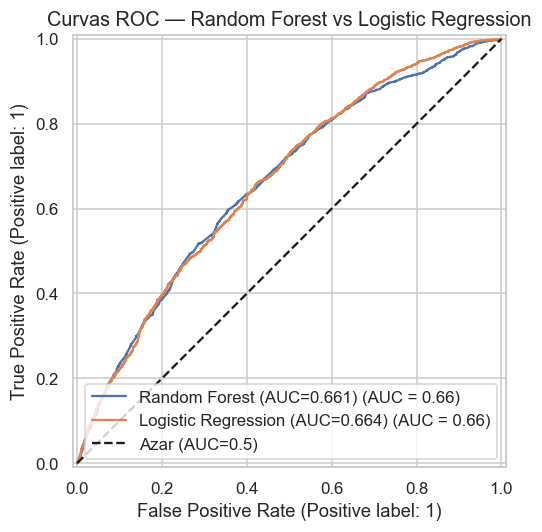

In [10]:
# Curvas ROC
fig, ax = plt.subplots(figsize=(7, 5))
colores_roc = ["#4C72B0", "#DD8452"]

for (nombre, res), color in zip(resultados.items(), colores_roc):
    RocCurveDisplay.from_predictions(
        y_test, res["y_proba"],
        name=f"{nombre} (AUC={res['roc_auc']:.3f})",
        ax=ax, color=color
    )

ax.plot([0, 1], [0, 1], "k--", label="Azar (AUC=0.5)")
ax.set_title("Curvas ROC — Random Forest vs Logistic Regression", fontsize=13)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


---
## Paso 6 — Análisis de Resultados

### Criterio de selección
Se usa **F1-Score** como métrica principal porque el dataset está desbalanceado (69% exitosos).  
El F1 pondera precision y recall, siendo más informativo que accuracy en este contexto.

### Trade-offs
- **Random Forest** captura relaciones no lineales entre tags. Mejor F1 y recall, más lento.
- **Logistic Regression** asume linealidad. Más rápido e interpretable, menor recall.

### Errores más importantes
Los **Falsos Negativos (FN)** son más costosos: predecir que un juego *no* será exitoso  
cuando sí lo sería implica perder una oportunidad de inversión o desarrollo.  
→ Un **recall alto** en la clase `Exitoso` es prioritario.

### Limitaciones
1. Los tags son asignados por usuarios y pueden ser subjetivos.
2. El éxito depende de factores no capturados: marketing, precio, competencia.
3. Posible sesgo temporal: juegos recientes tienen más reviews que juegos antiguos.


In [11]:
# Determinar ganador
f1_rf = resultados["Random Forest"]["f1"]
f1_lr = resultados["Logistic Regression"]["f1"]
ganador = "Random Forest" if f1_rf >= f1_lr else "Logistic Regression"

print(f"★ Mejor modelo por F1-Score: {ganador}")
print()
print("Reportes detallados por clase:")
for nombre, res in resultados.items():
    print(f"\n─── {nombre} ───")
    print(classification_report(y_test, res["y_pred"], target_names=["No exitoso", "Exitoso"]))


★ Mejor modelo por F1-Score: Random Forest

Reportes detallados por clase:

─── Random Forest ───
              precision    recall  f1-score   support

  No exitoso       0.53      0.28      0.36      1406
     Exitoso       0.73      0.89      0.80      3101

    accuracy                           0.70      4507
   macro avg       0.63      0.58      0.58      4507
weighted avg       0.67      0.70      0.67      4507


─── Logistic Regression ───
              precision    recall  f1-score   support

  No exitoso       0.43      0.59      0.50      1406
     Exitoso       0.78      0.64      0.70      3101

    accuracy                           0.63      4507
   macro avg       0.60      0.62      0.60      4507
weighted avg       0.67      0.63      0.64      4507



---
## Paso 7 — Tags Más Importantes para Predecir Éxito


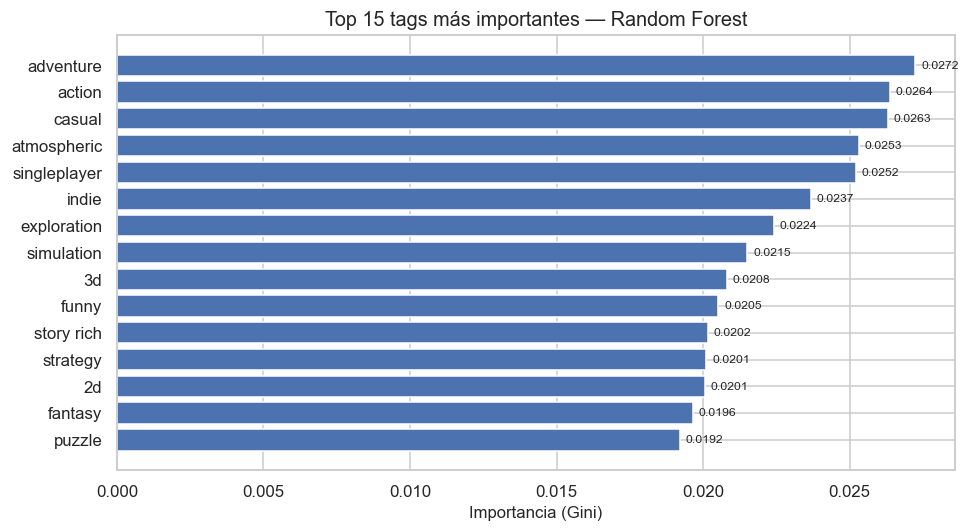

In [12]:
# Random Forest: feature importances
rf_model     = resultados["Random Forest"]["modelo"]
importancias = pd.Series(rf_model.feature_importances_, index=tag_cols).sort_values(ascending=False)
top_imp      = importancias.head(15)
top_imp.index = [i.replace("tag_", "").replace("_", " ") for i in top_imp.index]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_imp.index[::-1], top_imp.values[::-1], color="#4C72B0", edgecolor="white")
ax.set_xlabel("Importancia (Gini)", fontsize=11)
ax.set_title("Top 15 tags más importantes — Random Forest", fontsize=13)
for i, (val, name) in enumerate(zip(top_imp.values[::-1], top_imp.index[::-1])):
    ax.text(val + 0.0002, i, f"{val:.4f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()


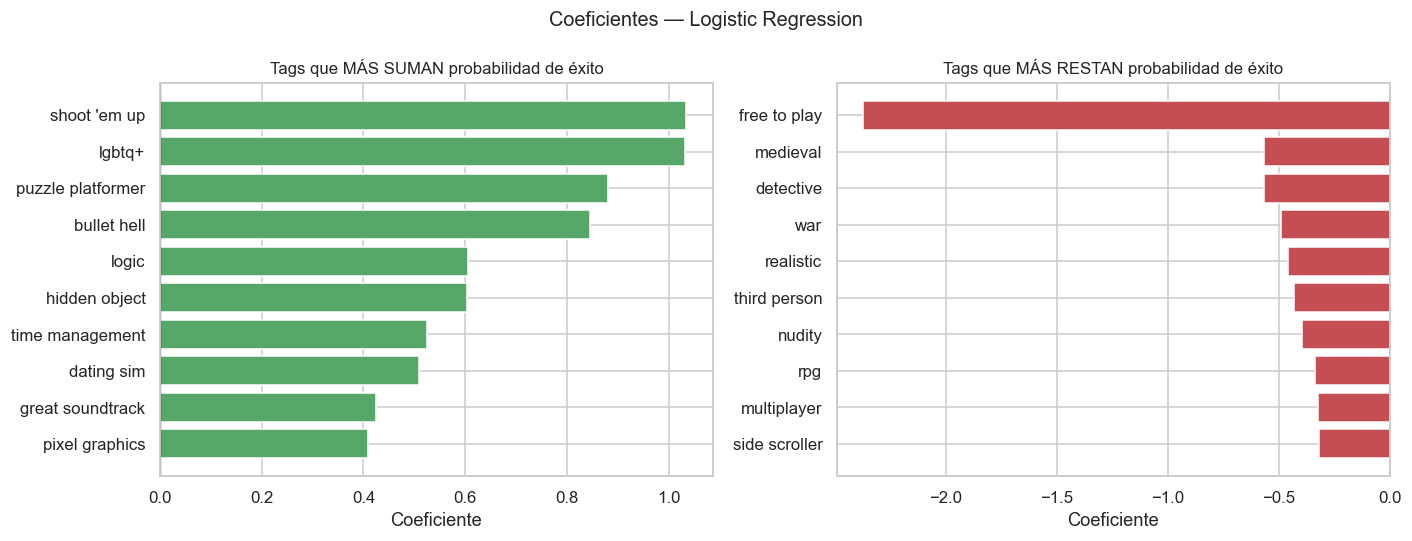

In [13]:
# Logistic Regression: coeficientes
lr_model = resultados["Logistic Regression"]["modelo"]
coefs    = pd.Series(lr_model.coef_[0], index=tag_cols)

top_pos = coefs.sort_values(ascending=False).head(10)
top_neg = coefs.sort_values(ascending=True).head(10)
top_pos.index = [i.replace("tag_", "").replace("_", " ") for i in top_pos.index]
top_neg.index = [i.replace("tag_", "").replace("_", " ") for i in top_neg.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Tags que suman éxito
axes[0].barh(top_pos.index[::-1], top_pos.values[::-1], color="#55A868", edgecolor="white")
axes[0].set_title("Tags que MÁS SUMAN probabilidad de éxito", fontsize=11)
axes[0].set_xlabel("Coeficiente")
axes[0].axvline(0, color="black", linewidth=0.8)

# Tags que restan éxito
axes[1].barh(top_neg.index[::-1], top_neg.values[::-1], color="#C44E52", edgecolor="white")
axes[1].set_title("Tags que MÁS RESTAN probabilidad de éxito", fontsize=11)
axes[1].set_xlabel("Coeficiente")
axes[1].axvline(0, color="black", linewidth=0.8)

plt.suptitle("Coeficientes — Logistic Regression", fontsize=13)
plt.tight_layout()
plt.show()


---
## Paso 8 — Ejemplos de Uso del Modelo

Aplicamos el mejor modelo a **4 casos concretos**.  
Dado un conjunto de tags, el modelo entrega:
- **Predicción**: `Exitoso` o `No exitoso`
- **Probabilidad**: % de confianza en que el juego será exitoso


In [14]:
mejor_modelo = resultados[ganador]["modelo"]

def predecir_juego(nombre_ejemplo, tags_activos):
    vector = pd.DataFrame([[0] * len(tag_cols)], columns=tag_cols)
    encontrados = []
    for tag in tags_activos:
        col = f"tag_{tag.replace(' ', '_')}"
        if col in vector.columns:
            vector[col] = 1
            encontrados.append(tag)

    prediccion   = mejor_modelo.predict(vector)[0]
    probabilidad = mejor_modelo.predict_proba(vector)[0][1]
    etiqueta     = "✅ EXITOSO" if prediccion == 1 else "❌ NO EXITOSO"

    print(f"{'─'*55}")
    print(f"  Ejemplo : {nombre_ejemplo}")
    print(f"  Tags    : {', '.join(encontrados)}")
    print(f"  Resultado  : {etiqueta}  ({probabilidad*100:.1f}%)")
    if probabilidad >= 0.7:
        print("  Análisis: Alta probabilidad — perfil de tags consistente")
        print("            con juegos exitosos en Steam.")
    elif probabilidad >= 0.4:
        print("  Análisis: Probabilidad moderada — combinación de tags")
        print("            no determinante para el éxito.")
    else:
        print("  Análisis: Baja probabilidad — perfil de tags asociado")
        print("            mayormente a juegos no exitosos.")
    print()

print(f"Modelo usado: {ganador}\n")

predecir_juego("Juego indie 2D tipo puzzle",
               ["indie", "2d", "puzzle", "pixel_graphics", "cute"])

predecir_juego("Shooter multijugador realista free-to-play",
               ["multiplayer", "first_person", "realistic", "pvp", "free_to_play"])

predecir_juego("RPG mundo abierto en tercera persona",
               ["rpg", "open_world", "third_person", "story_rich", "action"])

predecir_juego("Estrategia retro con historia",
               ["strategy", "retro", "story_rich", "indie", "difficult"])


Modelo usado: Random Forest

───────────────────────────────────────────────────────
  Ejemplo : Juego indie 2D tipo puzzle
  Tags    : indie, 2d, puzzle, pixel_graphics, cute
  Resultado  : ✅ EXITOSO  (87.8%)
  Análisis: Alta probabilidad — perfil de tags consistente
            con juegos exitosos en Steam.

───────────────────────────────────────────────────────
  Ejemplo : Shooter multijugador realista free-to-play
  Tags    : multiplayer, first_person, realistic, pvp, free_to_play
  Resultado  : ❌ NO EXITOSO  (9.3%)
  Análisis: Baja probabilidad — perfil de tags asociado
            mayormente a juegos no exitosos.

───────────────────────────────────────────────────────
  Ejemplo : RPG mundo abierto en tercera persona
  Tags    : rpg, open_world, third_person, story_rich, action
  Resultado  : ❌ NO EXITOSO  (38.5%)
  Análisis: Baja probabilidad — perfil de tags asociado
            mayormente a juegos no exitosos.

───────────────────────────────────────────────────────
  Ejemplo

---
## Resumen Final


In [15]:
print("=" * 60)
print("RESUMEN FINAL")
print("=" * 60)
print(f"Problema  : Predecir si un juego Steam será exitoso")
print(f"Features  : {len(tag_cols)} tags binarios")
print(f"Dataset   : {len(df):,} juegos  ({pct_exit:.1f}% exitosos)")
print(f"División  : 80% train / 20% test (estratificado)")
print()

tabla_final = pd.DataFrame(
    {nombre: {
        "Accuracy" : res["accuracy"],
        "Precision": res["precision"],
        "Recall"   : res["recall"],
        "F1-Score" : res["f1"],
        "ROC-AUC"  : res["roc_auc"]
    } for nombre, res in resultados.items()}
).round(4)

display(tabla_final.style.format("{:.4f}").background_gradient(cmap="Blues"))

print(f"\n★ Modelo recomendado: {ganador}")
print(f"  Justificación: Mayor F1-Score, mejor balance precision/recall")
print(f"  en un dataset con clases desbalanceadas (69/31).")


RESUMEN FINAL
Problema  : Predecir si un juego Steam será exitoso
Features  : 134 tags binarios
Dataset   : 22,531 juegos  (68.8% exitosos)
División  : 80% train / 20% test (estratificado)



,Random Forest,Logistic Regression
Accuracy,0.6989,0.6268
Precision,0.7307,0.7751
Recall,0.8907,0.6446
F1-Score,0.8028,0.7039
ROC-AUC,0.6610,0.6640



★ Modelo recomendado: Random Forest
  Justificación: Mayor F1-Score, mejor balance precision/recall
  en un dataset con clases desbalanceadas (69/31).
